# GNN Model to predict charge for $N_2$ on $Fe(111)$

In [ ]:
from mlcolvar.cvs import RegressionCV
from mlcolvar.data import DictModule
from mlcolvar.utils.trainer import MetricsCallback
from mlcolvar.utils.plot import plot_metrics
from mlcolvar.utils.io import create_dataset_from_trajectories
from mlcolvar.core.nn.graph.schnet import SchNetModel

from lightning import Trainer
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks.model_checkpoint import ModelCheckpoint
from torch import no_grad
from torch.optim import lr_scheduler

from ase.io import read, write

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

In [2]:
!mkdir ML

mkdir: cannot create directory ‘ML’: File exists


## Create Dataset

In [3]:
sampling_traj_with_traget = np.arange(0, 200001, 10)
sampling = np.random.choice(len(sampling_traj_with_traget), size=1000, replace=False)

sampling_traj = sampling_traj_with_traget[sampling]

trajectories = []
for i, index in enumerate(tqdm(sampling_traj)):
    structure = read("OPES_2/traj_comp.traj", index)
    structure.set_pbc([True, True, True])
    trajectories.append(structure)
write("ML/traj.xyz", trajectories)

node_labels = np.loadtxt("OPES_2/CHARGES")[sampling]
graph_labels = (node_labels[:,72]+node_labels[:,73])/2
np.savetxt("ML/graph_labels.npy", graph_labels)

100%|██████████| 1000/1000 [00:12<00:00, 77.93it/s]


In [4]:
dataset = create_dataset_from_trajectories(
    trajectories="ML/traj.xyz",
    topologies=None,
    cutoff=4.5,
    graph_labels=[graph_labels.tolist()],
    node_labels=None,
    system_selection="type N",
    environment_selection="not type N",
    show_progress=False,
)

datamodule = DictModule(dataset, shuffle=[True, False]) #, batch_size=512

/home/gguiard@iit.local/miniforge3/envs/md_env/lib/python3.11/site-packages/mlcolvar/data/graph/utils.py:64: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  graph_labels = torch.tensor( config.graph_labels, dtype=torch.get_default_dtype() )   if config.graph_labels is not None else None


## Create Model

In [5]:
gnn_model = SchNetModel(
    n_out=1,
    cutoff=dataset.metadata["cutoff"],
    atomic_numbers=dataset.metadata["atomic_numbers"],
)

options = {
    'optimizer': {'lr': 1e-3},
    'lr_scheduler': {
        'scheduler': lr_scheduler.ExponentialLR,
        'gamma': 0.9999
    }
}

model = RegressionCV(gnn_model, options=options)

/home/gguiard@iit.local/miniforge3/envs/md_env/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


## Train Model

In [6]:
metrics = MetricsCallback()
early_stopping = EarlyStopping(monitor="valid_loss", patience=20)
checkpoint = ModelCheckpoint(save_top_k=1, monitor="valid_loss")

trainer = Trainer(
    callbacks=[metrics, early_stopping, checkpoint],
    logger=True,
    enable_checkpointing=True,
    max_epochs=5000,
    enable_model_summary=False,
    enable_progress_bar=False,
)

trainer.fit(model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/gguiard@iit.local/miniforge3/envs/md_env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA RTX A4000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float3

## Make Plots

/home/gguiard@iit.local/miniforge3/envs/md_env/lib/python3.11/site-packages/mlcolvar/data/datamodule.py:341: UserWarning: Length of split at index 1 is 0. This might result in an empty dataset.
  warnings.warn(


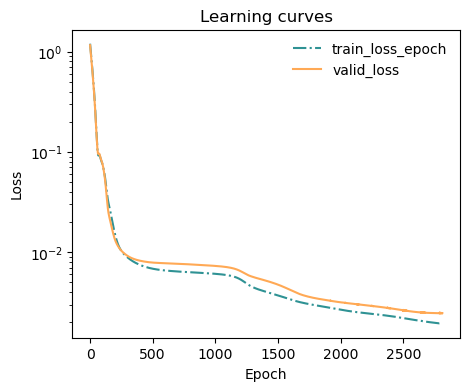

In [7]:
ax = plot_metrics(
    metrics.metrics,          
    keys=['train_loss_epoch', 'valid_loss'],
    linestyles=['-.','-'],
    colors=['fessa1','fessa5'],
    yscale='log',
)

model.to_torchscript("ML/model.ptc", method="trace")
plt.savefig("ML/plot_metrics.svg")

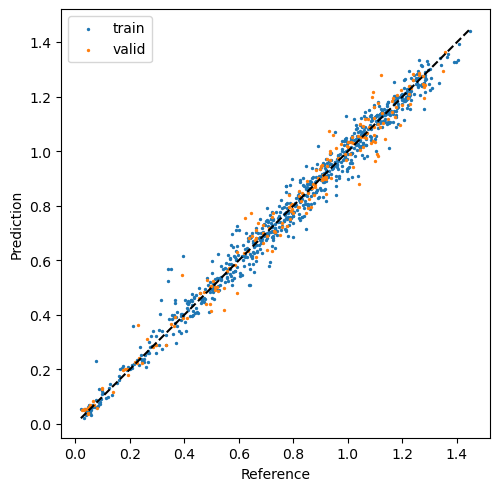

In [8]:
model.eval()

train_indices = datamodule._dataset_split[0].indices
valid_indices = datamodule._dataset_split[1].indices

ref_train = graph_labels[train_indices]
ref_valid = graph_labels[valid_indices]

with no_grad():
    pred = model(dataset.get_graph_inputs()).detach().squeeze()

pred_train = pred[train_indices]
pred_valid = pred[valid_indices]

min_value = min(min(ref_valid), min(ref_train), min(pred_valid), min(pred_train))
max_value = max(max(ref_valid), max(ref_train), max(pred_valid), max(pred_train))

fig, ax = plt.subplots(layout='constrained')
ax.plot([min_value, max_value], [min_value, max_value], color='k', linestyle='--')
ax.scatter(ref_train, pred_train, s=2, label="train")
ax.scatter(ref_valid, pred_valid, s=2, label="valid")

ax.set_xlabel("Reference")
ax.set_ylabel("Prediction")
ax.legend()
ax.set_aspect('equal', 'box')

fig.savefig("ML/pred_trainvalid.svg")